In [134]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

(<Figure size 640x480 with 1 Axes>,
 (np.float64(-0.5), np.float64(499.5), np.float64(533.5), np.float64(-0.5)),
 Text(0.5, 1.0, 'Original Image'))

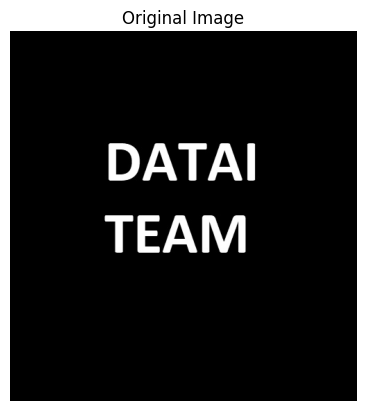

In [135]:
img = cv2.imread("datai_team.jpg", 0)
plt.figure(), plt.imshow(img, cmap="gray"), plt.axis('off'), plt.title("Original Image")

(<Figure size 640x480 with 1 Axes>,
 (np.float64(-0.5), np.float64(499.5), np.float64(533.5), np.float64(-0.5)),
 Text(0.5, 1.0, 'Erode Image'))

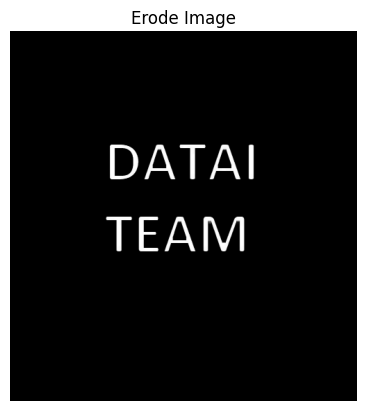

In [136]:
# erode -> ön plandaki nesnenin sınırlarını aşındırır (beyaz bölgeyi azaltır)
kernel = np.ones((5,5), dtype=np.uint8)
result = cv2.erode(img, kernel, iterations=1)  # iterationsu artırırsak daha da küçülür
plt.figure(), plt.imshow(result, cmap="gray"), plt.axis('off'), plt.title("Erode Image")

(<Figure size 640x480 with 1 Axes>,
 (np.float64(-0.5), np.float64(499.5), np.float64(533.5), np.float64(-0.5)),
 Text(0.5, 1.0, 'Dilate Image'))

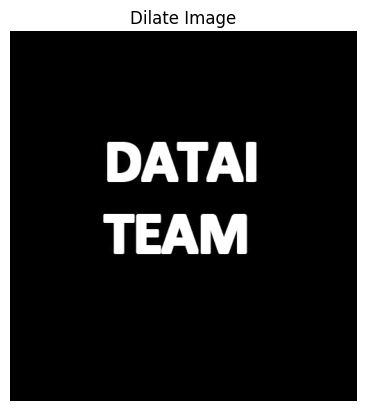

In [137]:
# dilation -> erozyonun tam tersidir. beyaz bölgeyi artırır
result2 = cv2.dilate(img, kernel, iterations=1)
plt.figure(), plt.imshow(result2, cmap="gray"), plt.axis('off'), plt.title("Dilate Image")

(<Figure size 640x480 with 1 Axes>,
 (np.float64(-0.5), np.float64(499.5), np.float64(533.5), np.float64(-0.5)),
 Text(0.5, 1.0, 'White Noised Image'))

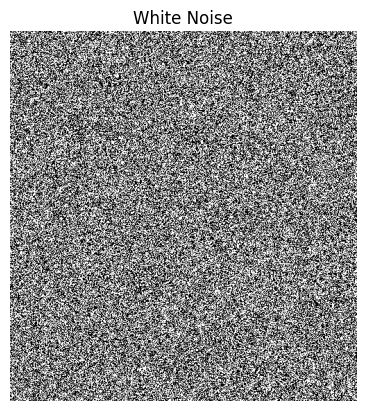

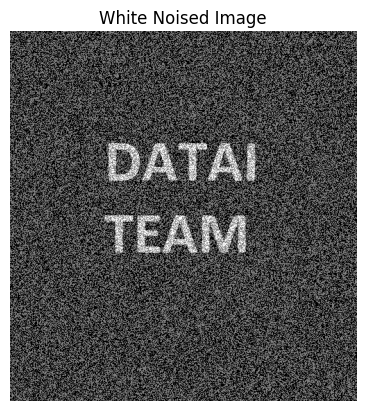

In [138]:
# opening yöntemi için white noise ekleyip bakacaz
white_noise = np.random.randint(0,2, size=img.shape[:2]) # channei ile işimiz yok diye :2 dedik
white_noise = white_noise * 255
plt.figure(), plt.imshow(white_noise, cmap="gray"), plt.axis('off'), plt.title("White Noise")

white_noise_img = white_noise + img
plt.figure(), plt.imshow(white_noise_img, cmap="gray"), plt.axis('off'), plt.title("White Noised Image")

(<Figure size 640x480 with 1 Axes>,
 (np.float64(-0.5), np.float64(499.5), np.float64(533.5), np.float64(-0.5)),
 Text(0.5, 1.0, 'Opening Image'))

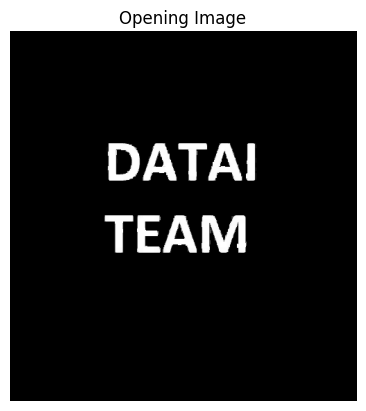

In [139]:
# opening, erosion ile küçük beyaz gürültüyü bastırır; ardından dilation ile erozyonla küçülen ana yapıları kısmen geri genişletir
opening = cv2.morphologyEx(white_noise_img.astype(np.float32), cv2.MORPH_OPEN, kernel)
plt.figure(), plt.imshow(opening, cmap="gray"), plt.axis('off'), plt.title("Opening Image")

(<Figure size 640x480 with 1 Axes>,
 (np.float64(-0.5), np.float64(499.5), np.float64(533.5), np.float64(-0.5)),
 Text(0.5, 1.0, 'Black Noise Image'))

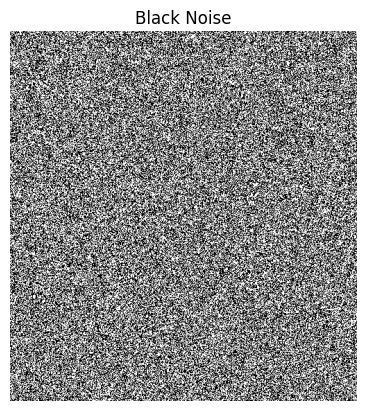

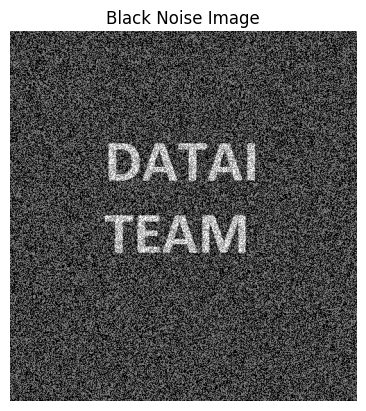

In [140]:
# black noise
black_noise = np.random.randint(0,2, size=img.shape[:2])
black_noise = black_noise * -255
plt.figure(), plt.imshow(black_noise, cmap="gray"), plt.axis('off'), plt.title("Black Noise")

black_noise_img = black_noise + img
black_noise_img[black_noise_img == 0] = 0
plt.figure(), plt.imshow(black_noise_img, cmap="gray"), plt.axis('off'), plt.title("Black Noise Image")

(<Figure size 640x480 with 1 Axes>,
 (np.float64(-0.5), np.float64(499.5), np.float64(533.5), np.float64(-0.5)),
 Text(0.5, 1.0, 'Closing Image'))

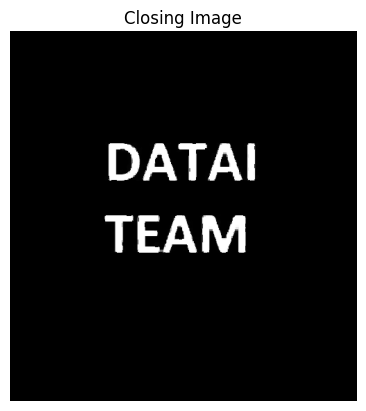

In [143]:
  # closing -> first dilation, after that erosion

closing = cv2.morphologyEx(black_noise_img.astype(np.float32), cv2.MORPH_CLOSE, kernel)
plt.figure(), plt.imshow(closing, cmap="gray"), plt.axis('off'), plt.title("Closing Image")


(<Figure size 640x480 with 1 Axes>,
 (np.float64(-0.5), np.float64(499.5), np.float64(533.5), np.float64(-0.5)),
 Text(0.5, 1.0, 'Gradient'))

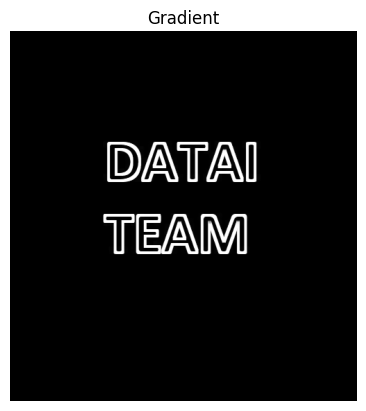

In [144]:
# morphological gradient  -> dilation - erotion
gradient = cv2.morphologyEx(img, cv2.MORPH_GRADIENT, kernel)
plt.figure(), plt.imshow(gradient, cmap="gray"), plt.axis('off'), plt.title("Gradient")